# Gold: tópicos (`governor_discourse_topics` + `topic_priority_score`)

ADR [0022](../../docs/adr/0022-notebooks-de-diagnostico-medallion-separados-da-narrativa-do-tcc.md)
(issue [#128](https://github.com/Vini0606/Tecnicas-de-Ciencia-de-Dados-em-dados-do-Instagram/issues/128)).

**Duas tabelas de tópicos independentes, com espaços de tópico diferentes -- não confundir os
IDs de `Topic` entre elas** (ver comentário em `src/schemas_delta.py` acima de
`GOLD_TOPIC_PRIORITY_SCORE_SCHEMA`):

- **`governor_discourse_topics`**: tópicos da FALA DA ASSESSORIA (legenda + transcrição dos
  próprios posts/reels do governador). Uma linha por post/reel.
- **`topic_priority_score`**: Score ICE (Impacto x Confiança x Facilidade) sobre os tópicos DO QUE
  O PÚBLICO COMENTA (mesmo espaço de tópico de `governor_sentiment.Topic`, não o de
  `governor_discourse_topics.Topic`). Ranking **global**, não por governador.

Notebook estritamente leitura via `DeltaRepository`, mesmo princípio da ADR
[0003](../../docs/adr/0003-desacoplar-modelagem-do-notebook-via-scripts-cli-com-checkpoint.md).

In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from config import settings
from src.repositories.delta_repository import DeltaRepository
from src.visualization.charts import plot_top_n_bar, plot_scatter
from src.analysis.medallion_diagnostics import (
    completeness_summary,
    count_duplicate_rows,
    with_governor_metadata,
)

load_dotenv()
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

repo = DeltaRepository(gold_dir=settings.GOLD_DIR, silver_dir=settings.SILVER_DIR)

# Parte A -- `governor_discourse_topics` (fala da assessoria)

## A.1. Carga + schema

In [2]:
df_discurso = repo.load_discourse_topics()
df_discurso.dtypes

id_reel                       object
text                          object
inputUrl                      object
ownerUsername                 object
timestamp                     object
fonte                         object
Topic                          int64
Name                          object
_run_id                       object
_generated_at    datetime64[us, UTC]
dtype: object

## A.2. Completude

In [3]:
completude = completeness_summary(df_discurso)
print(f"linhas duplicadas (por id_reel): {count_duplicate_rows(df_discurso, subset=['id_reel'])}")
completude[completude['n_nulos'] > 0]

linhas duplicadas (por id_reel): 245


,coluna,dtype,n_nulos,pct_nulos,n_unicos
1,text,object,277,39.9135,406


## A.3. Distribuição: tamanho de cada tópico

`Topic == -1` é ruído do BERTopic (posts que não se encaixam em nenhum cluster coerente), não um
tópico de conteúdo real. Alguns `Name` aparecem vazios (ex.: `"0____"`) -- sinal de tópico ainda sem
refinamento via Gemini (`scripts/refine_topics.py`, ADR 0001) rodado sobre este `_run_id`.

In [4]:
contagem_topicos = df_discurso.groupby(['Topic', 'Name']).size().reset_index(name='n_posts')
plot_top_n_bar(contagem_topicos, x='n_posts', y='Name', title='Tópicos de discurso por volume de posts', top_n=10)

## A.4. Evolução temporal

Sem tabela `_history` irmã para `governor_discourse_topics` hoje -- seção do esqueleto padrão
pulada de propósito (nada a mostrar, não é uma omissão).

## A.5. Relação com covariáveis (partido/UF)

Quais partidos concentram qual tópico -- proporção de posts por partido dentro de cada tópico (não
contagem bruta, que seria dominada pelos partidos com mais posts no geral).

In [5]:
df_discurso_metadado = with_governor_metadata(df_discurso, repo.load_governors_metadata())
tabela_cruzada = pd.crosstab(df_discurso_metadado['Name'], df_discurso_metadado['partido'], normalize='index') * 100
tabela_cruzada.round(1)

partido,MDB,NOVO,PL,PP,PSB,PSD,PSDB,PT,Republicanos,Solidariedade,UNIÃO
Name,,,,,,,,,,,
-1_raquelnodebate_governadora_pernambuco_importantes,11.5000,13.5000,1.9000,0.0000,5.8000,17.3000,25.0000,13.5000,0.0000,0.0000,11.5000
0____,8.2000,10.7000,1.1000,4.3000,6.8000,15.4000,12.9000,22.5000,3.6000,6.4000,8.2000
10_12h30_11h45_estaremos_21h30,0.0000,40.0000,0.0000,0.0000,0.0000,0.0000,20.0000,40.0000,0.0000,0.0000,0.0000
1_alagoas_aforçadonovotempo_joãopratodaobra_clécioluís,8.9000,2.5000,3.0000,2.5000,13.4000,21.8000,12.9000,6.4000,6.4000,13.9000,8.4000
2_mobiliza_0001_elmano_jero13,1.1000,0.0000,0.0000,13.6000,0.0000,1.1000,0.0000,84.1000,0.0000,0.0000,0.0000
3_gladsoncameli_democrata_0001_osenadordetodos,0.0000,0.0000,0.0000,71.4000,0.0000,7.1000,0.0000,0.0000,0.0000,0.0000,21.4000
4_0001_vote_político_democrático,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000
5_precisamos_conosco_intocáveis_brasil,0.0000,88.9000,0.0000,0.0000,0.0000,0.0000,0.0000,11.1000,0.0000,0.0000,0.0000
6_marabá_paraense_próspero_parazão,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## A.6. Outliers

Tópicos com `Name` vazio (não refinados) ou com volume muito baixo de posts (candidatos a ruído
mesmo fora do `-1` explícito).

In [6]:
topicos_sem_nome = contagem_topicos[contagem_topicos['Name'].str.contains(r'^-?\d+_?_*$', regex=True, na=True)]
topicos_raros = contagem_topicos[contagem_topicos['n_posts'] <= 2]
print(f'{len(topicos_sem_nome)} tópicos sem refinamento de nome, {len(topicos_raros)} tópicos com <=2 posts')
pd.concat([topicos_sem_nome, topicos_raros]).drop_duplicates().sort_values('n_posts')

1 tópicos sem refinamento de nome, 0 tópicos com <=2 posts


,Topic,Name,n_posts
1,0,0____,280


## A.7. Nota de interpretação

Compare `contagem_topicos` com o `_run_id` em `df_discurso['_run_id'].unique()` antes de concluir
que um tópico é raro de forma estável -- pode ser só uma execução com corpus pequeno (poucos posts
novos desde a última extração).

# Parte B -- `topic_priority_score` (Score ICE de comentários)

## B.1. Carga + schema

Ranking **global** (uma linha por tópico de comentário, não por governador).

In [7]:
df_priority = repo.load_topic_priority_score()
df_priority.dtypes

Topic                                          int64
Name                                          object
n_comentarios                                  int64
alcance_topico                                 int64
alcance_normalizado                          float64
proporcao_sentimento_positivo                float64
confianca                                    float64
impacto                                      float64
facilidade                                   float64
score                                        float64
_run_id                                       object
_generated_at                    datetime64[us, UTC]
dtype: object

## B.2. Completude

In [8]:
completude_priority = completeness_summary(df_priority)
print(f"linhas duplicadas (por Topic): {count_duplicate_rows(df_priority, subset=['Topic'])}")
completude_priority[completude_priority['n_nulos'] > 0]

linhas duplicadas (por Topic): 0


,coluna,dtype,n_nulos,pct_nulos,n_unicos


## B.3. Distribuições univariadas das componentes do score

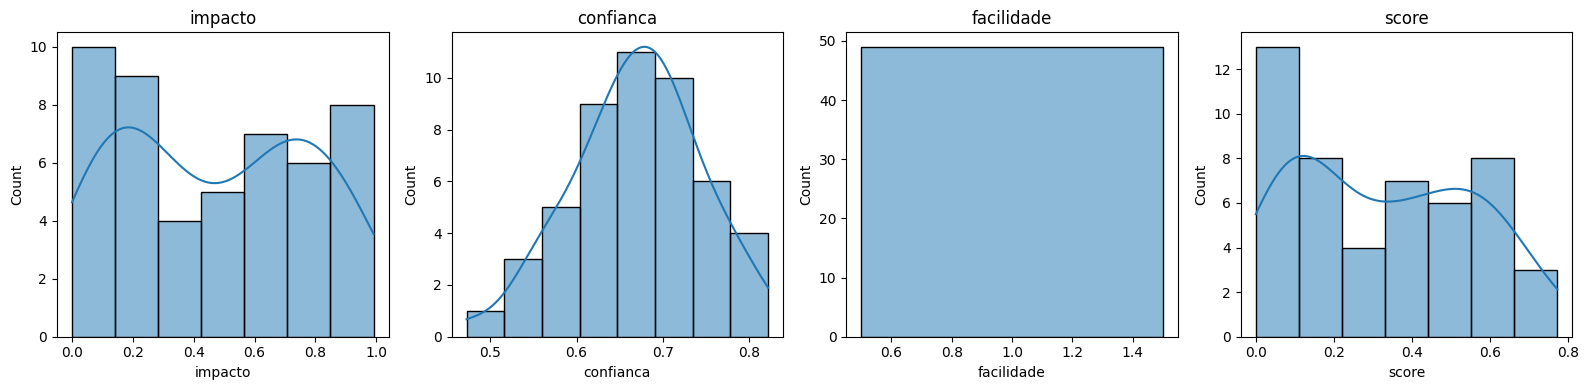

In [9]:
componentes = ['impacto', 'confianca', 'facilidade', 'score']
fig, axes = plt.subplots(1, len(componentes), figsize=(4 * len(componentes), 4))
for ax, coluna in zip(axes, componentes):
    sns.histplot(df_priority[coluna], kde=True, ax=ax)
    ax.set_title(coluna)
plt.tight_layout()
plt.show()

## B.4. Relação: score vs. proporção de sentimento positivo

Um tópico de alto score mas alta proporção positiva pode ser prioridade "errada" de responder --
score prioriza volume x alcance x facilidade, não sentimento.

In [10]:
plot_scatter(df_priority, x='proporcao_sentimento_positivo', y='score', color=None)

## B.5. Outliers: top e bottom do ranking

In [11]:
colunas_exibir = ['Topic', 'Name', 'n_comentarios', 'score', 'proporcao_sentimento_positivo']
print('--- top 5 (maior prioridade) ---')
display(df_priority.sort_values('score', ascending=False)[colunas_exibir].head())
print('--- bottom 5 (menor prioridade) ---')
display(df_priority.sort_values('score', ascending=True)[colunas_exibir].head())

--- top 5 (maior prioridade) ---


,Topic,Name,n_comentarios,score,proporcao_sentimento_positivo
0,9,9_mãos_aplaudindo_mãos_aplaudindo_pele_clara_p...,77,0.7723,0.9740
1,18,18_rosto_sorridente_com_olhos_de_coração_mãos_...,43,0.7113,0.9535
2,11,11_coração_vermelho_coração_verde_coração_amar...,65,0.6987,0.9846
3,8,8_mãos_aplaudindo_pele_clara_mãos_aplaudindo_p...,79,0.6569,0.9873
4,0,0_mãos_aplaudindo_mãos_para_cima_aperto_de_mão...,817,0.6295,0.9963


--- bottom 5 (menor prioridade) ---


,Topic,Name,n_comentarios,score,proporcao_sentimento_positivo
48,44,44_voto_votar_vota_urnas,16,0.0000,0.0625
47,35,35_coração_azul_balão_de_diálogo_à_esquerda_on...,25,0.0000,0.7200
46,22,22_cem_pontos_5511_55055_556,37,0.0085,0.0270
45,7,7_13___,80,0.0325,0.0625
44,36,36_tecla_3_tecla_1_tecla_0_tac,25,0.0486,0.0800


## B.6. Nota de interpretação

Cruzar os `Name` do top do Score ICE (Parte B) com os tópicos de discurso mais frequentes (Parte A)
responde uma pergunta concreta de assessoria: a assessoria já fala sobre o que o público mais
prioriza nos comentários, ou há uma lacuna temática entre os dois?